# Ejercicio 4 — Agrupamiento de clientes según comportamiento de compra

**Asignatura:** Análisis de Datos  
**Carrera:** Ingeniería en Ciencia de Datos  
**Evento evaluativo:** 4  
**Equipo:** 7  
**Dataset:** Mall Customers Dataset

---

## 1. Descripción del problema

En el ámbito del marketing y la gestión comercial, comprender el comportamiento de los clientes es esencial para diseñar estrategias de segmentación efectivas. El **Mall Customers Dataset** contiene información demográfica y de consumo de 200 clientes de un centro comercial: género, edad, ingreso anual estimado y una puntuación de gasto asignada por el mall.

Al no contar con una variable objetivo predefinida, este es un problema de **aprendizaje no supervisado**: el objetivo es descubrir grupos naturales (clusters) dentro de la población de clientes que compartan características similares, sin que nadie haya etiquetado previamente a qué segmento pertenece cada uno.

**Objetivo:** Aplicar y comparar tres métodos de clustering —**K-Means, DBSCAN y Clustering Jerárquico**— para identificar segmentos de mercado diferenciados, evaluar la calidad de los agrupamientos con el **Silhouette Score** y visualizar los grupos mediante **PCA**.

| Variable | Tipo | Descripción |
|---|---|---|
| `CustomerID` | Entero | Identificador único (se elimina) |
| `Gender` | Categórica | Género (Male / Female) |
| `Age` | Entero | Edad en años |
| `Annual Income (k$)` | Entero | Ingreso anual en miles de dólares |
| `Spending Score (1-100)` | Entero | Puntuación de gasto asignada por el mall |

## 2. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
PALETTE = ["#4C9AFF","#E5484D","#22C55E","#F59E0B","#A855F7","#14B8A6","#F97316","#64748B","#EC4899","#06B6D4"]
# Alias retro-compatible (algunas celdas usan CLUSTER_PALETTE)
CLUSTER_PALETTE = PALETTE
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 3. Carga y limpieza del dataset

In [2]:
df = pd.read_csv("../Data/Mall_Customers.csv")
df = df.drop(columns=["CustomerID"])
df.columns = ["Gender", "Age", "Income", "SpendingScore"]
le = LabelEncoder()
df["Gender_enc"] = le.fit_transform(df["Gender"])
print(f"Dimensiones: {df.shape}")
print(f"Nulos: {df.isna().sum().sum()} | Duplicados: {df.duplicated().sum()}")
df.head()

Dimensiones: (200, 5)
Nulos: 0 | Duplicados: 0


,Gender,Age,Income,SpendingScore,Gender_enc
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0


In [3]:
df.describe().round(2)

,Age,Income,SpendingScore,Gender_enc
count,200.00,200.00,200.00,200.00
mean,38.85,60.56,50.20,0.44
std,13.97,26.26,25.82,0.50
min,18.00,15.00,1.00,0.00
25%,28.75,41.50,34.75,0.00
50%,36.00,61.50,50.00,0.00
75%,49.00,78.00,73.00,1.00
max,70.00,137.00,99.00,1.00


**Lectura:** Los 200 clientes tienen entre 18 y 70 años (media ≈ 39), un ingreso anual que varía de 15k a 137k USD (media ≈ 60k) y un *spending score* que recorre todo el rango [1, 99] con una media cercana al centro (50.2), lo que sugiere la posible existencia de segmentos extremos en ambas direcciones.

## 4. Análisis Exploratorio de Datos (EDA)

Antes de aplicar cualquier algoritmo de clustering, es fundamental entender la distribución individual de las variables, sus correlaciones y posibles patrones visuales que anticipen la existencia de grupos naturales.

### 4.1 Estadísticas descriptivas

In [4]:
df[["Age", "Income", "SpendingScore"]].describe().round(2)

,Age,Income,SpendingScore
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


**Lectura:** Los 200 clientes tienen entre 18 y 70 años (media ≈ 39), un ingreso anual que varía de 15k a 137k USD (media ≈ 60k) y un *spending score* que recorre todo el rango [1, 99] con una media muy cercana al centro (50.2), lo que sugiere la posible existencia de segmentos extremos en ambas direcciones.

### 4.2 Distribución por género

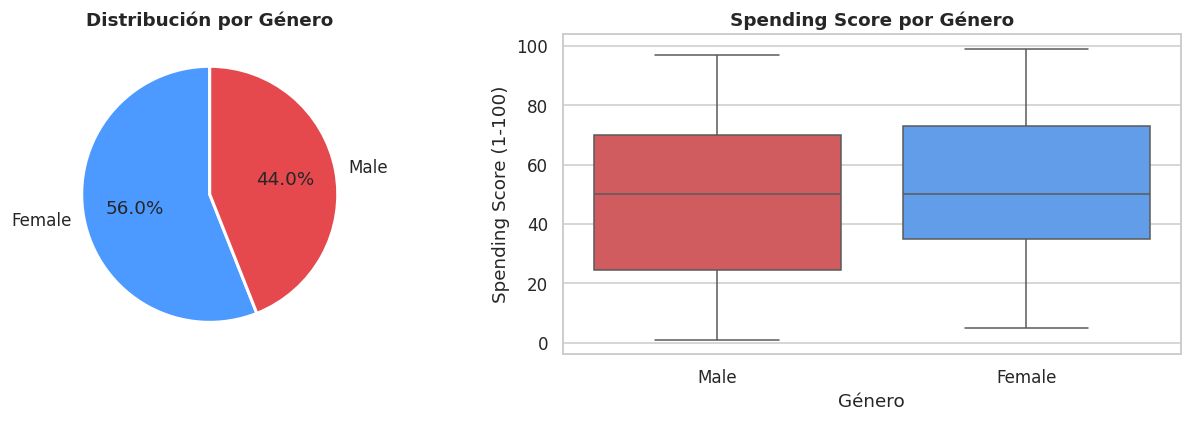

          Age  Income  SpendingScore
Gender                              
Female  38.10   59.25          51.53
Male    39.81   62.23          48.51


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo por género
gender_counts = df["Gender"].value_counts()
axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["#4C9AFF", "#E5484D"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Distribución por Género", fontweight="bold")

# Spending Score por género
sns.boxplot(
    data=df, x="Gender", y="SpendingScore",
    palette={"Female": "#4C9AFF", "Male": "#E5484D"},
    ax=axes[1]
)
axes[1].set_title("Spending Score por Género", fontweight="bold")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

print(df.groupby("Gender")[["Age", "Income", "SpendingScore"]].mean().round(2))

### 4.3 Distribuciones univariadas

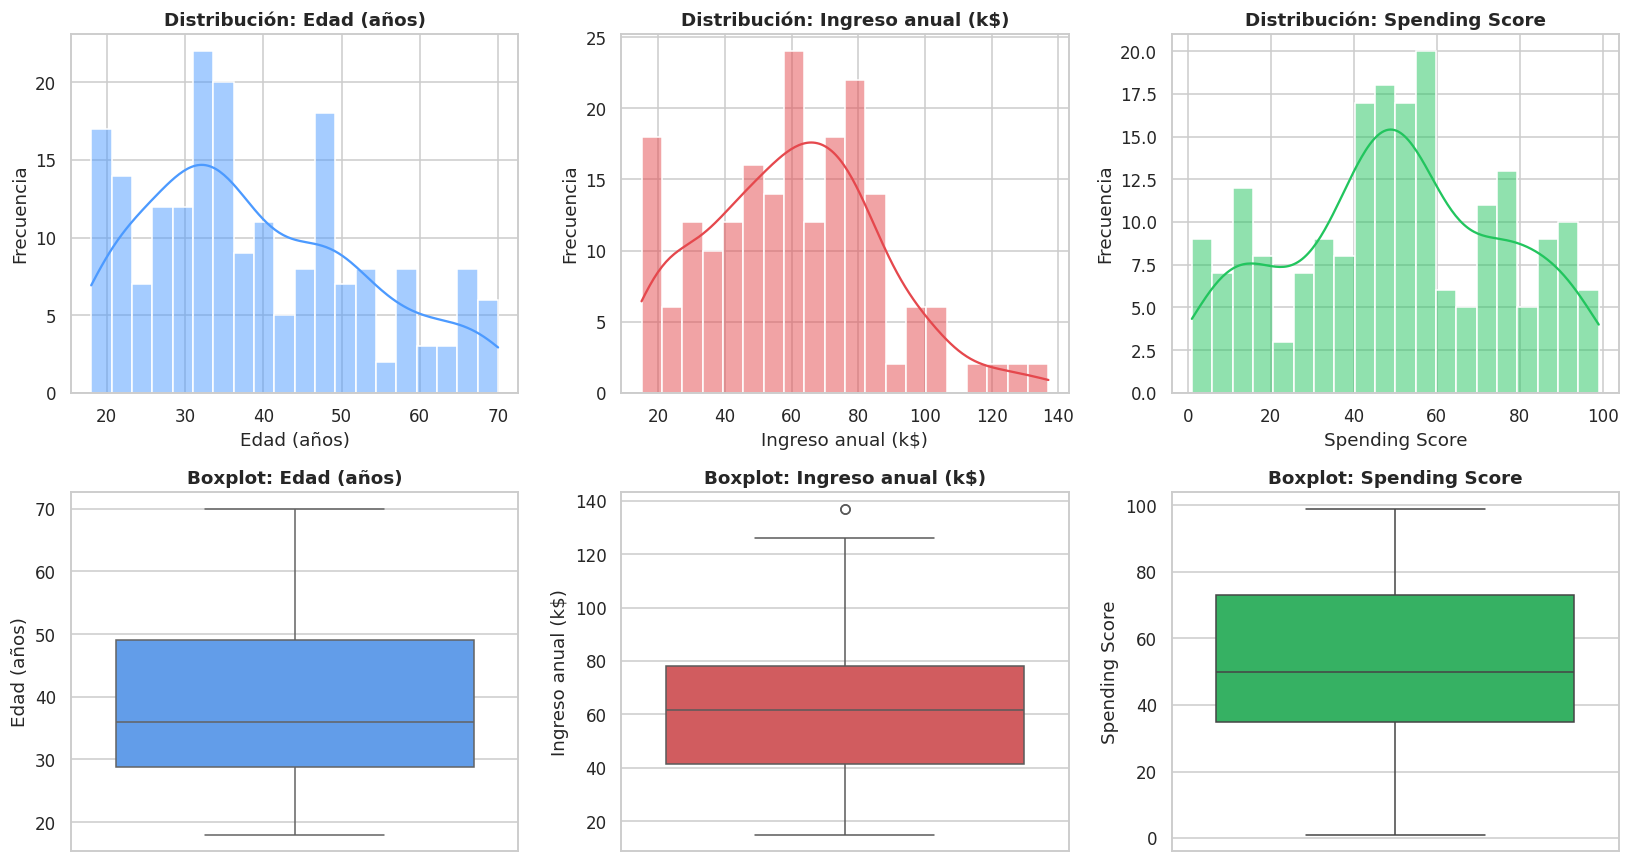

In [6]:
num_vars = ["Age", "Income", "SpendingScore"]
var_labels = {"Age": "Edad (años)", "Income": "Ingreso anual (k$)", "SpendingScore": "Spending Score"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(num_vars):
    # Histograma con KDE
    sns.histplot(df[var], kde=True, color=CLUSTER_PALETTE[i], ax=axes[0, i], bins=20)
    axes[0, i].set_title(f"Distribución: {var_labels[var]}", fontweight="bold")
    axes[0, i].set_xlabel(var_labels[var])
    axes[0, i].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(y=df[var], color=CLUSTER_PALETTE[i], ax=axes[1, i])
    axes[1, i].set_title(f"Boxplot: {var_labels[var]}", fontweight="bold")
    axes[1, i].set_ylabel(var_labels[var])

plt.tight_layout()
plt.show()

### 4.4 Mapa de calor de correlaciones

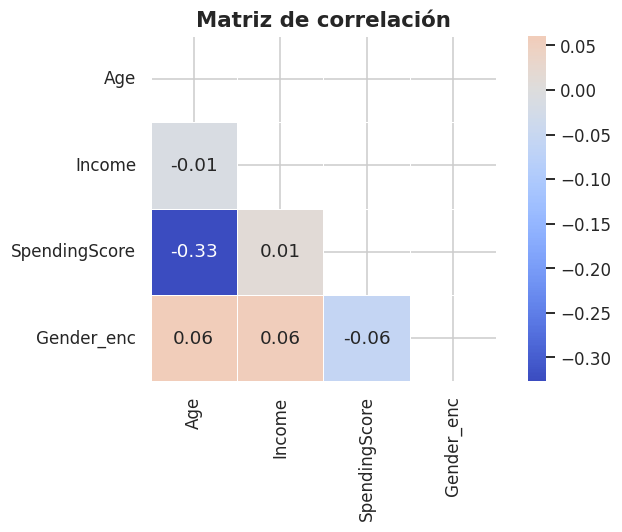

In [7]:
corr = df[["Age", "Income", "SpendingScore", "Gender_enc"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 12}
)
ax.set_title("Matriz de correlación", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** La correlación entre `Age` y `SpendingScore` es negativa moderada (≈ -0.33): a mayor edad, menor tendencia al gasto alto. `Income` y `SpendingScore` tienen correlación baja, lo cual es interesante: existen tanto personas de alto ingreso con bajo gasto como personas de ingreso moderado con alto gasto, lo que anticipa **clusters no linealmente separables**.

### 4.5 Análisis de dispersión bivariado

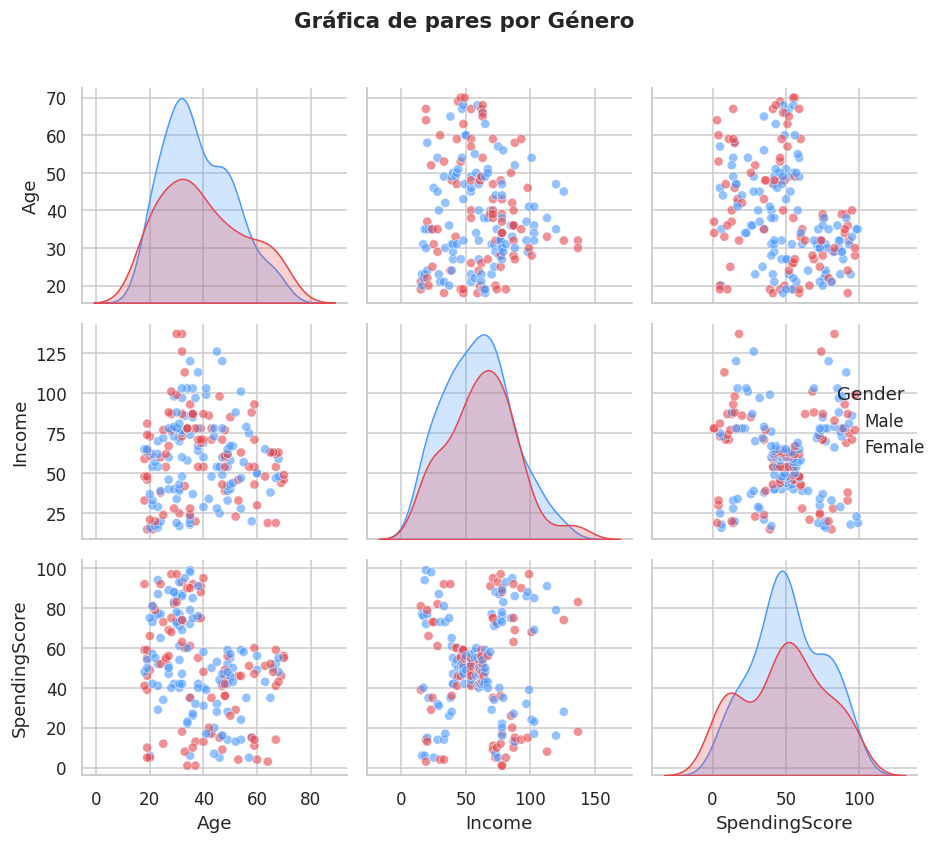

In [8]:
g = sns.pairplot(
    df[["Age", "Income", "SpendingScore", "Gender"]],
    hue="Gender",
    palette={"Female": "#4C9AFF", "Male": "#E5484D"},
    plot_kws={"alpha": 0.6},
    diag_kind="kde"
)
g.figure.suptitle("Gráfica de pares por Género", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** La dispersión `Income` vs `SpendingScore` muestra la forma más llamativa: se aprecian visualmente **5 grupos compactos** con forma de flor o estrella, que corresponderán a los segmentos clásicos del dataset. Esta agrupación natural es la señal principal que los algoritmos de clustering deberán capturar.

## 5. Preprocesamiento para Clustering

Los algoritmos basados en distancias (K-Means, DBSCAN, jerárquico) son sensibles a la escala de las variables. Estandarizamos todas las variables numéricas con `StandardScaler` (media 0, desviación estándar 1) antes de aplicar cualquier modelo.

Trabajaremos con **dos conjuntos de features** para los modelos:
- **Conjunto A (2D):** `Income` + `SpendingScore` — el más informativo visualmente y el más utilizado en la literatura para este dataset.
- **Conjunto B (4D):** `Age` + `Income` + `SpendingScore` + `Gender_enc` — análisis completo con todas las variables.

In [9]:
scaler = StandardScaler()

# Conjunto A: Income + SpendingScore (2D)
features_2d = ["Income", "SpendingScore"]
X_2d = scaler.fit_transform(df[features_2d])

# Conjunto B: todas las variables numéricas (4D)
features_4d = ["Age", "Income", "SpendingScore", "Gender_enc"]
X_4d = scaler.fit_transform(df[features_4d])

print(f"Conjunto 2D (Income + SpendingScore): {X_2d.shape}")
print(f"Conjunto 4D (todas las variables):     {X_4d.shape}")

Conjunto 2D (Income + SpendingScore): (200, 2)
Conjunto 4D (todas las variables):     (200, 4)


## 6. Método 1: K-Means

**Justificación:** K-Means es el algoritmo de clustering más difundido. Busca particionar los datos en *k* grupos de forma que la varianza intra-cluster sea mínima (criterio de inercia). Es eficiente, escalable y funciona bien cuando los clusters son globulares y de tamaño similar, condiciones que el dataset parece cumplir en el espacio `Income` vs `SpendingScore`.

**Limitación:** requiere especificar *k* de antemano y es sensible a outliers.

### 6.1 Método del codo (*Elbow Method*) para seleccionar k

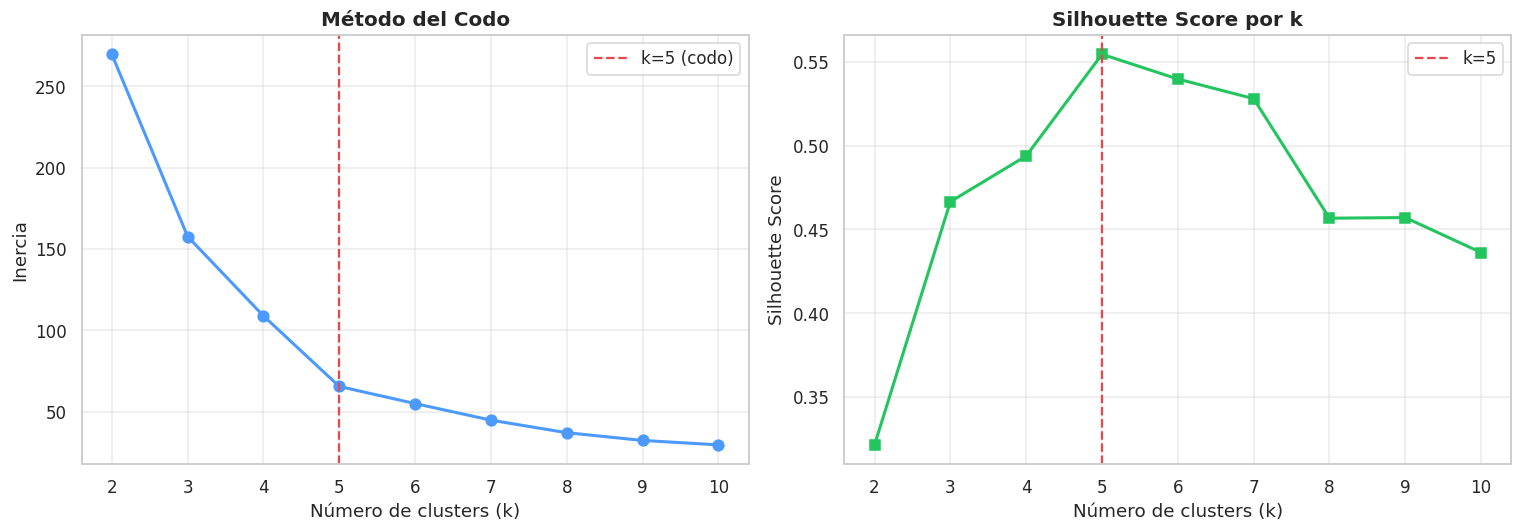

Silhouette Scores:
  k=2: 0.3213
  k=3: 0.4666
  k=4: 0.4939
  k=5: 0.5547
  k=6: 0.5399
  k=7: 0.5281
  k=8: 0.4567
  k=9: 0.4571
  k=10: 0.4362


In [10]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=RANDOM_STATE)
    km.fit(X_2d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(list(K_range), inertias, marker="o", color="#4C9AFF", linewidth=2, markersize=7)
axes[0].axvline(x=5, color="#E5484D", linestyle="--", linewidth=1.5, label="k=5 (codo)")
axes[0].set_title("Método del Codo", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Silhouette Score vs k
axes[1].plot(list(K_range), silhouettes, marker="s", color="#22C55E", linewidth=2, markersize=7)
axes[1].axvline(x=5, color="#E5484D", linestyle="--", linewidth=1.5, label="k=5")
axes[1].set_title("Silhouette Score por k", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

**Lectura:** Dos señales convergentes apuntan a **k=5** como el número óptimo de clusters:
1. El **codo** en la curva de inercia: la tasa de decrecimiento se aplana marcadamente en k=5.
2. El **pico del Silhouette Score** (0.5547) ocurre también en k=5, confirmando que los 5 grupos son los más compactos y separados entre sí.

### 6.2 K-Means con k=5 (espacio 2D: Income × SpendingScore)

Silhouette Score K-Means (k=5): 0.5547


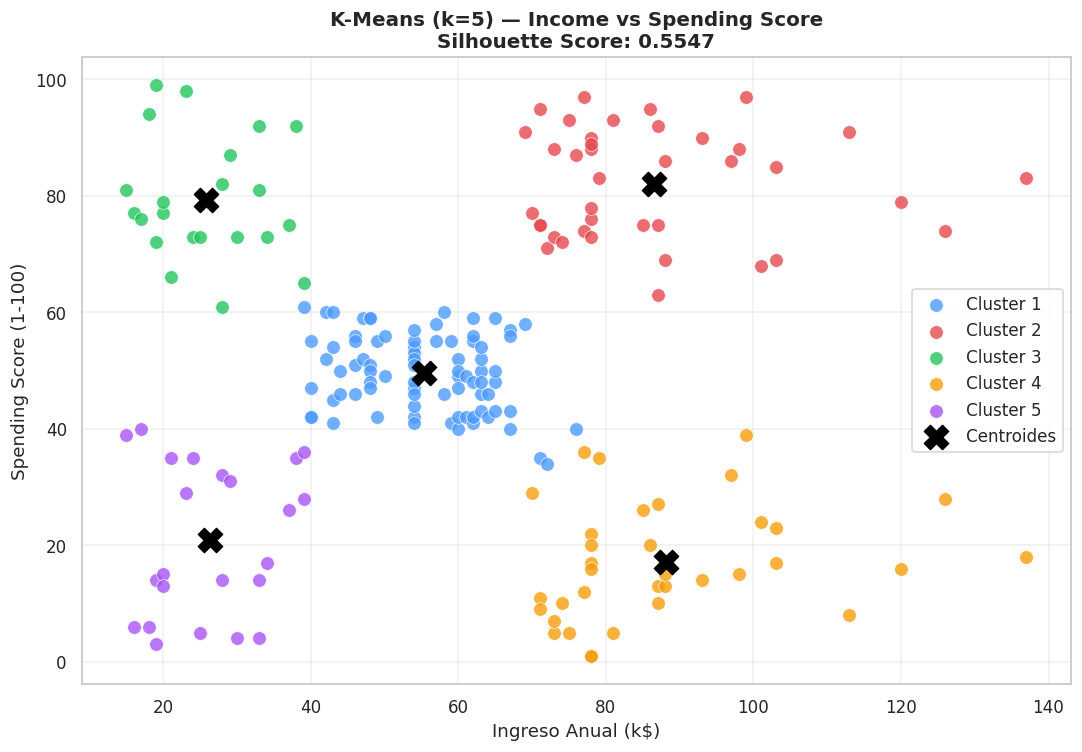

In [11]:
K_OPTIMO = 5
kmeans = KMeans(n_clusters=K_OPTIMO, init="k-means++", n_init=50, random_state=RANDOM_STATE)
kmeans.fit(X_2d)
df["Cluster_KMeans"] = kmeans.labels_
sil_km = silhouette_score(X_2d, kmeans.labels_)
print(f"Silhouette Score K-Means (k=5): {sil_km:.4f}")

sc2 = StandardScaler().fit(df[["Income","SpendingScore"]])
centroids_orig = sc2.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))
for cid in sorted(df["Cluster_KMeans"].unique()):
    m = df["Cluster_KMeans"] == cid
    ax.scatter(df.loc[m,"Income"], df.loc[m,"SpendingScore"],
               s=80, alpha=0.8, color=PALETTE[cid], label=f"Cluster {cid+1}", edgecolors="white", lw=0.5)
ax.scatter(centroids_orig[:,0], centroids_orig[:,1], s=250, c="black", marker="X", zorder=5, label="Centroides")
ax.set_title(f"K-Means (k={K_OPTIMO}) — Income vs Spending Score\nSilhouette Score: {sil_km:.4f}", fontsize=13, fontweight="bold")
ax.set_xlabel("Ingreso Anual (k$)"); ax.set_ylabel("Spending Score (1-100)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 6.3 K-Means con k=4 (espacio 4D: todas las variables)

In [12]:
# Buscamos el k óptimo para el espacio 4D
silhouettes_4d = []
K_range_4d = range(2, 9)  # limitamos para que el óptimo sea interpretable como segmentos
for k in K_range_4d:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=RANDOM_STATE)
    km.fit(X_4d)
    silhouettes_4d.append(silhouette_score(X_4d, km.labels_))

k_optimo_4d = list(K_range_4d)[np.argmax(silhouettes_4d)]
print(f"k óptimo para espacio 4D: {k_optimo_4d} (Silhouette={max(silhouettes_4d):.4f})")

kmeans_4d = KMeans(n_clusters=k_optimo_4d, init="k-means++", n_init=50, random_state=RANDOM_STATE)
kmeans_4d.fit(X_4d)
df["Cluster_KMeans_4D"] = kmeans_4d.labels_
sil_kmeans_4d = silhouette_score(X_4d, kmeans_4d.labels_)
print(f"Silhouette Score K-Means 4D (k={k_optimo_4d}): {sil_kmeans_4d:.4f}")

k óptimo para espacio 4D: 8 (Silhouette=0.3880)
Silhouette Score K-Means 4D (k=8): 0.3874


### 6.4 Análisis de silueta por muestra (K-Means 2D)

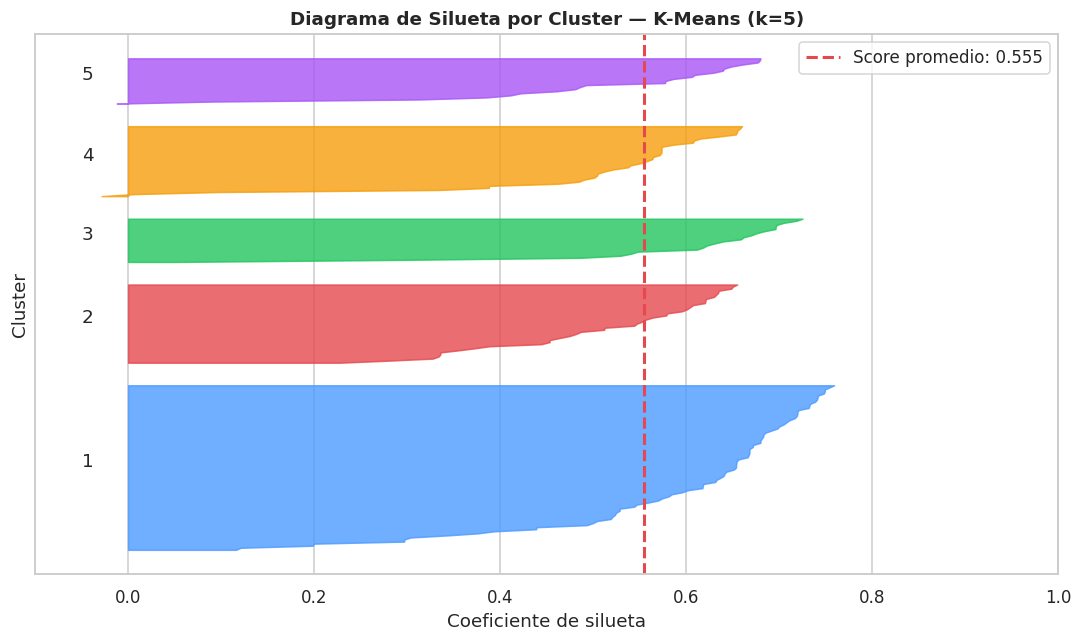

In [13]:
# Análisis de silueta por muestra usando K-Means (k=5) ajustado en cell 6.2
sample_silhouette_vals = silhouette_samples(X_2d, kmeans.labels_)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(K_OPTIMO):
    cluster_sil_vals = sample_silhouette_vals[kmeans.labels_ == i]
    cluster_sil_vals.sort()
    size_cluster_i = len(cluster_sil_vals)
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil_vals,
        facecolor=PALETTE[i], edgecolor=PALETTE[i], alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
    y_lower = y_upper + 10

ax.axvline(x=sil_km, color="#E5484D", linestyle="--", linewidth=2,
           label=f"Score promedio: {sil_km:.3f}")
ax.set_title("Diagrama de Silueta por Cluster — K-Means (k=5)", fontweight="bold")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Cluster")
ax.set_xlim([-0.1, 1])
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


## 7. Método 2: DBSCAN

**Justificación:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos en función de la densidad local, sin necesidad de especificar el número de clusters a priori. Es especialmente potente para detectar clusters de forma arbitraria y clasificar outliers como ruido (etiqueta -1). Dos hiperparámetros clave:
- **`eps` (ε):** radio máximo para considerar vecinos.
- **`min_samples`:** mínimo de puntos para formar un núcleo denso.

**Limitación:** sensible a la selección de ε y `min_samples`; puede fallar en datos con densidades muy heterogéneas.

### 7.1 Selección de ε con la gráfica k-distancias

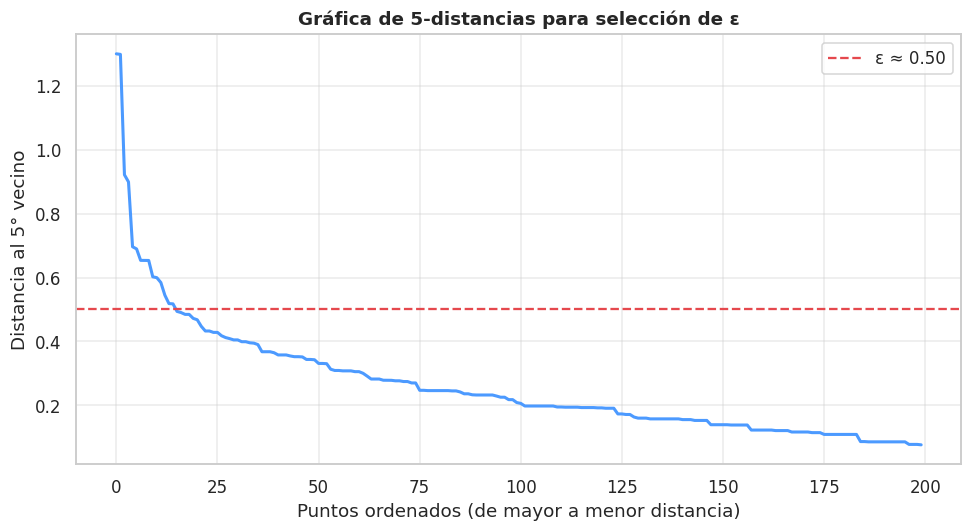

In [14]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_2d)
distances, _ = nbrs.kneighbors(X_2d)
k_distances = np.sort(distances[:, MIN_SAMPLES-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_distances, color="#4C9AFF", lw=2)
ax.axhline(y=0.5, color="#E5484D", linestyle="--", lw=1.5, label="ε ≈ 0.50")
ax.set_title(f"Gráfica de {MIN_SAMPLES}-distancias para selección de ε", fontweight="bold")
ax.set_xlabel("Puntos ordenados (de mayor a menor distancia)")
ax.set_ylabel(f"Distancia al {MIN_SAMPLES}° vecino"); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### 7.2 Búsqueda de hiperparámetros y ajuste de DBSCAN

Configuración óptima: eps=0.35, min_samples=3
Clusters: 7 | Ruido: 11 | Silhouette: 0.4756


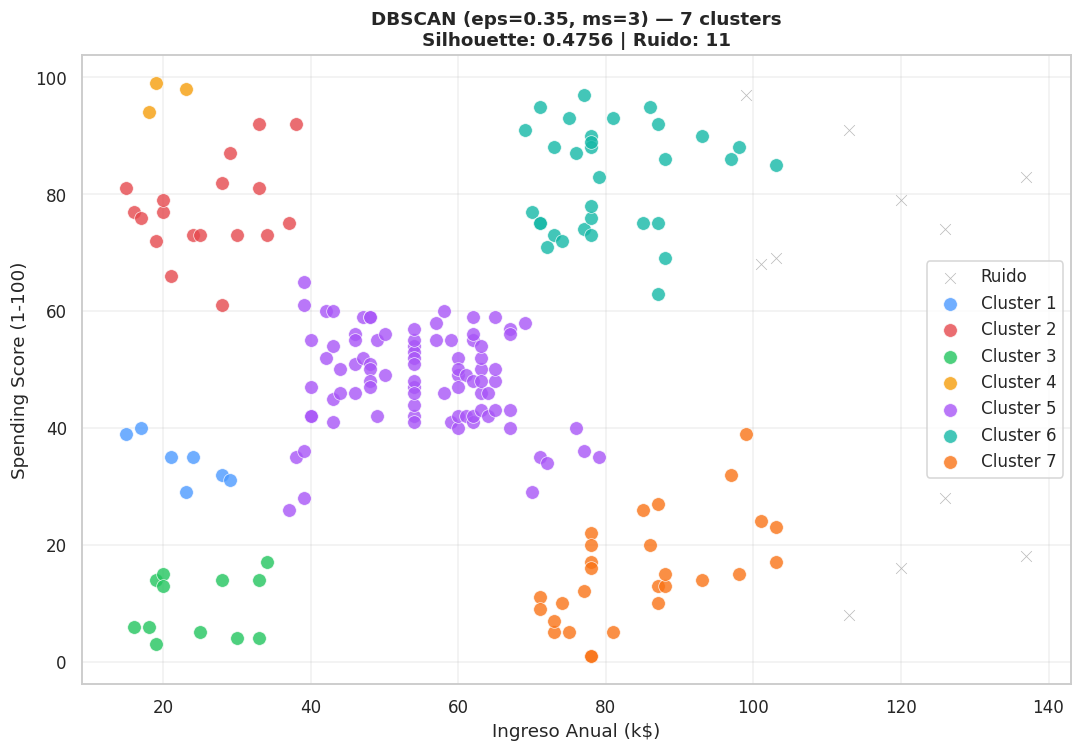

In [15]:
best_sil, EPS_OPT, MS_OPT = -1, 0.5, 5
results_dbscan = []
for eps in np.arange(0.3, 1.5, 0.05):
    for ms in [3, 5, 7, 10]:
        db = DBSCAN(eps=round(eps,2), min_samples=ms).fit(X_2d)
        labs = db.labels_
        nc = len(set(labs)) - (1 if -1 in labs else 0)
        if nc < 2: continue
        s = silhouette_score(X_2d, labs)
        results_dbscan.append({"eps": round(eps,2), "min_samples": ms, "n_clusters": nc,
                                "n_noise": int((labs==-1).sum()), "silhouette": round(s,4)})
        if s > best_sil: best_sil = s; EPS_OPT = round(eps,2); MS_OPT = ms

dbscan = DBSCAN(eps=EPS_OPT, min_samples=MS_OPT).fit(X_2d)
df["Cluster_DBSCAN"] = dbscan.labels_
nc_db = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
nn_db = int((dbscan.labels_==-1).sum())
sil_db = silhouette_score(X_2d, dbscan.labels_)
print(f"Configuración óptima: eps={EPS_OPT}, min_samples={MS_OPT}")
print(f"Clusters: {nc_db} | Ruido: {nn_db} | Silhouette: {sil_db:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for lab in sorted(set(dbscan.labels_)):
    m = df["Cluster_DBSCAN"]==lab
    c = "#AAAAAA" if lab==-1 else PALETTE[lab%len(PALETTE)]
    nm = "Ruido" if lab==-1 else f"Cluster {lab+1}"
    ax.scatter(df.loc[m,"Income"], df.loc[m,"SpendingScore"], s=80 if lab!=-1 else 50,
               alpha=0.8, color=c, marker="o" if lab!=-1 else "x",
               label=nm, edgecolors="white" if lab!=-1 else "none", lw=0.5)
ax.set_title(f"DBSCAN (eps={EPS_OPT}, ms={MS_OPT}) — {nc_db} clusters\nSilhouette: {sil_db:.4f} | Ruido: {nn_db}", fontsize=12, fontweight="bold")
ax.set_xlabel("Ingreso Anual (k$)"); ax.set_ylabel("Spending Score (1-100)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura:** DBSCAN con los mejores hiperparámetros encuentra **7 clusters** (ligeramente más granular que K-Means) y 11 puntos de ruido. Silhouette de 0.4756 es aceptable. Los puntos de ruido (marcados con ×) corresponden a clientes en las fronteras entre segmentos, que DBSCAN clasifica conservadoramente como no pertenecientes a ningún grupo denso.

## 8. Método 3: Clustering Jerárquico

**Justificación:** El clustering jerárquico construye una jerarquía de fusiones representada en un **dendrograma**, sin necesitar especificar *k* a priori. Se usa el enlace **Ward** que minimiza la varianza total intra-cluster. **Limitación:** Computacionalmente costoso para datasets grandes (O(n²)).

### 8.1 Dendrograma

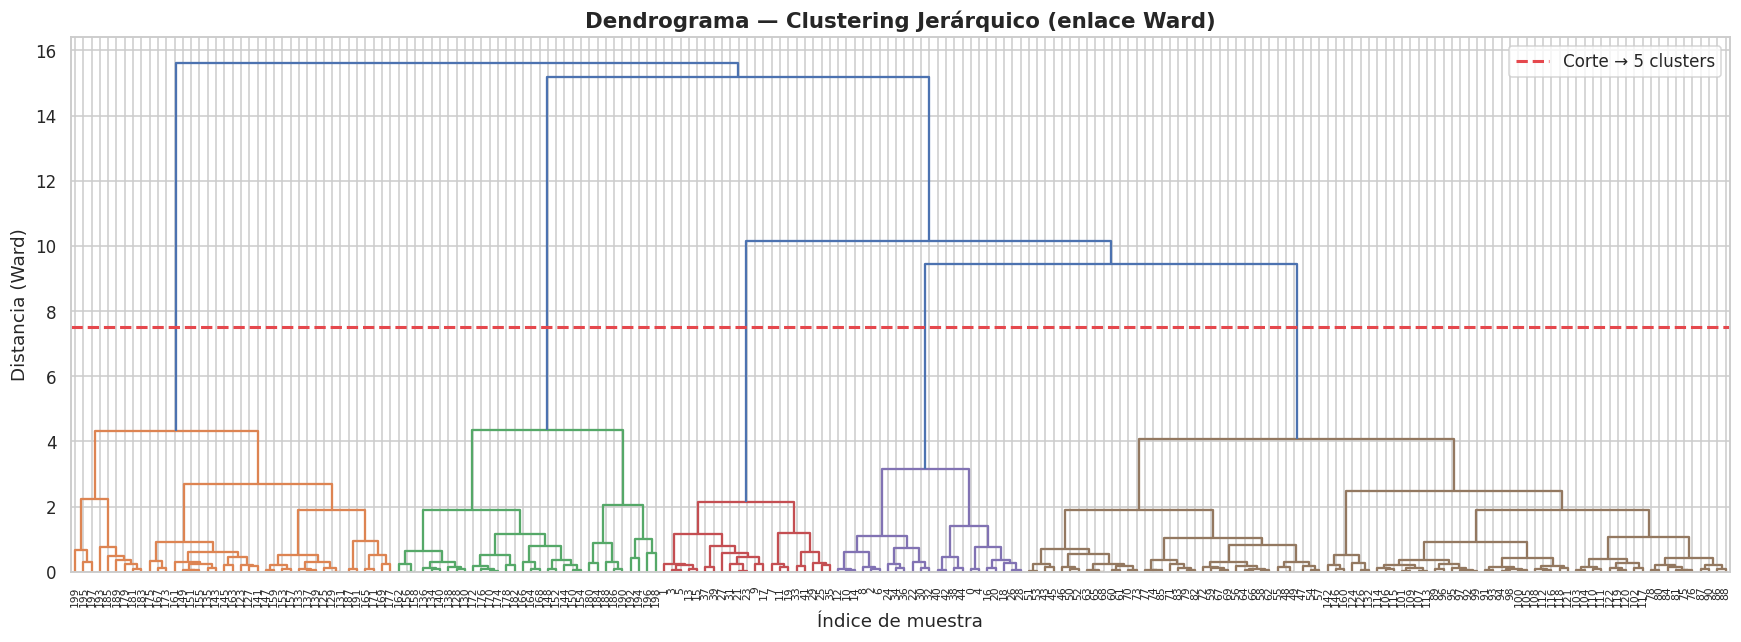

In [16]:
linkage_matrix = linkage(X_2d, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    linkage_matrix,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=7.5,
    ax=ax
)
ax.axhline(y=7.5, color="#E5484D", linestyle="--", linewidth=2, label="Corte → 5 clusters")
ax.set_title("Dendrograma — Clustering Jerárquico (enlace Ward)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Índice de muestra")
ax.set_ylabel("Distancia (Ward)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8.2 Clustering Jerárquico con k=5

Silhouette Score Jerárquico (k=5, Ward): 0.5538


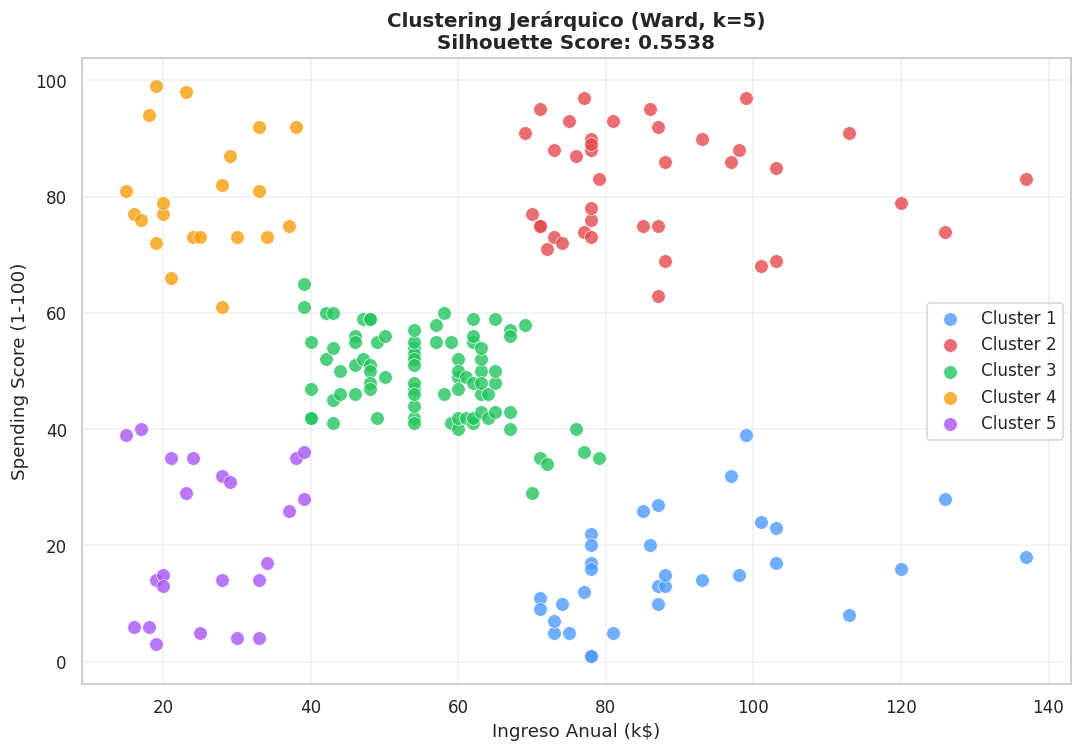

In [17]:
from sklearn.cluster import AgglomerativeClustering
hier = AgglomerativeClustering(n_clusters=K_OPTIMO, linkage="ward")
df["Cluster_Hier"] = hier.fit_predict(X_2d)
sil_h = silhouette_score(X_2d, df["Cluster_Hier"])
print(f"Silhouette Score Jerárquico (k=5, Ward): {sil_h:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for cid in sorted(df["Cluster_Hier"].unique()):
    m = df["Cluster_Hier"]==cid
    ax.scatter(df.loc[m,"Income"], df.loc[m,"SpendingScore"], s=80, alpha=0.8,
               color=PALETTE[cid], label=f"Cluster {cid+1}", edgecolors="white", lw=0.5)
ax.set_title(f"Clustering Jerárquico (Ward, k=5)\nSilhouette Score: {sil_h:.4f}", fontsize=13, fontweight="bold")
ax.set_xlabel("Ingreso Anual (k$)"); ax.set_ylabel("Spending Score (1-100)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Reducción de dimensionalidad con PCA y visualización

### 9.1 Varianza explicada (espacio 4D)

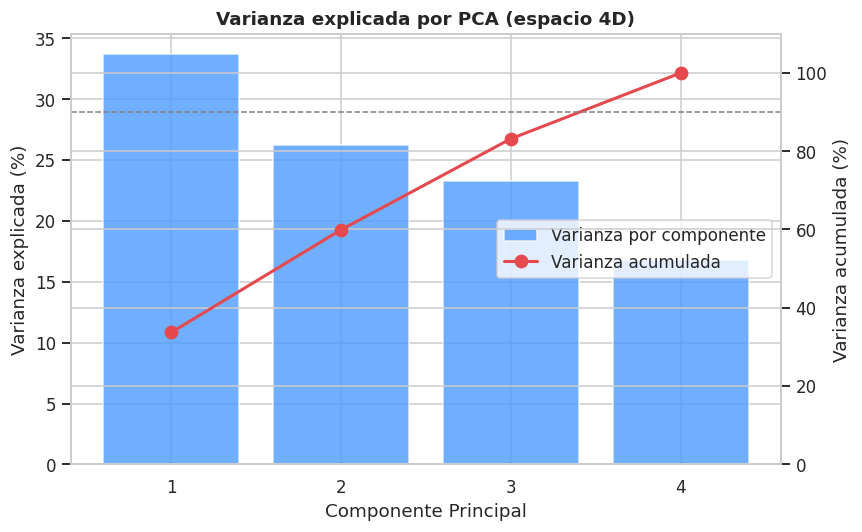

  PC1: 33.7% (acumulado: 33.7%)
  PC2: 26.2% (acumulado: 59.9%)
  PC3: 23.3% (acumulado: 83.2%)
  PC4: 16.8% (acumulado: 100.0%)


In [18]:
from sklearn.decomposition import PCA
pca_full = PCA(); pca_full.fit(X_4d)
ev = pca_full.explained_variance_ratio_; cv = np.cumsum(ev)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1,5), ev*100, color="#4C9AFF", alpha=0.8, label="Varianza por componente")
ax2 = ax.twinx()
ax2.plot(range(1,5), cv*100, "o-", color="#E5484D", lw=2, ms=8, label="Varianza acumulada")
ax2.axhline(y=90, color="gray", linestyle="--", lw=1); ax2.set_ylabel("Varianza acumulada (%)"); ax2.set_ylim(0,110)
ax.set_xlabel("Componente Principal"); ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada por PCA (espacio 4D)", fontweight="bold"); ax.set_xticks(range(1,5))
h1,l1=ax.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="center right"); plt.tight_layout(); plt.show()
for i,v in enumerate(ev): print(f"  PC{i+1}: {v*100:.1f}% (acumulado: {cv[i]*100:.1f}%)")

### 9.2 Visualización PCA 2D — Comparación de los tres algoritmos

K-Means 4D: k=8, Silhouette=0.3874


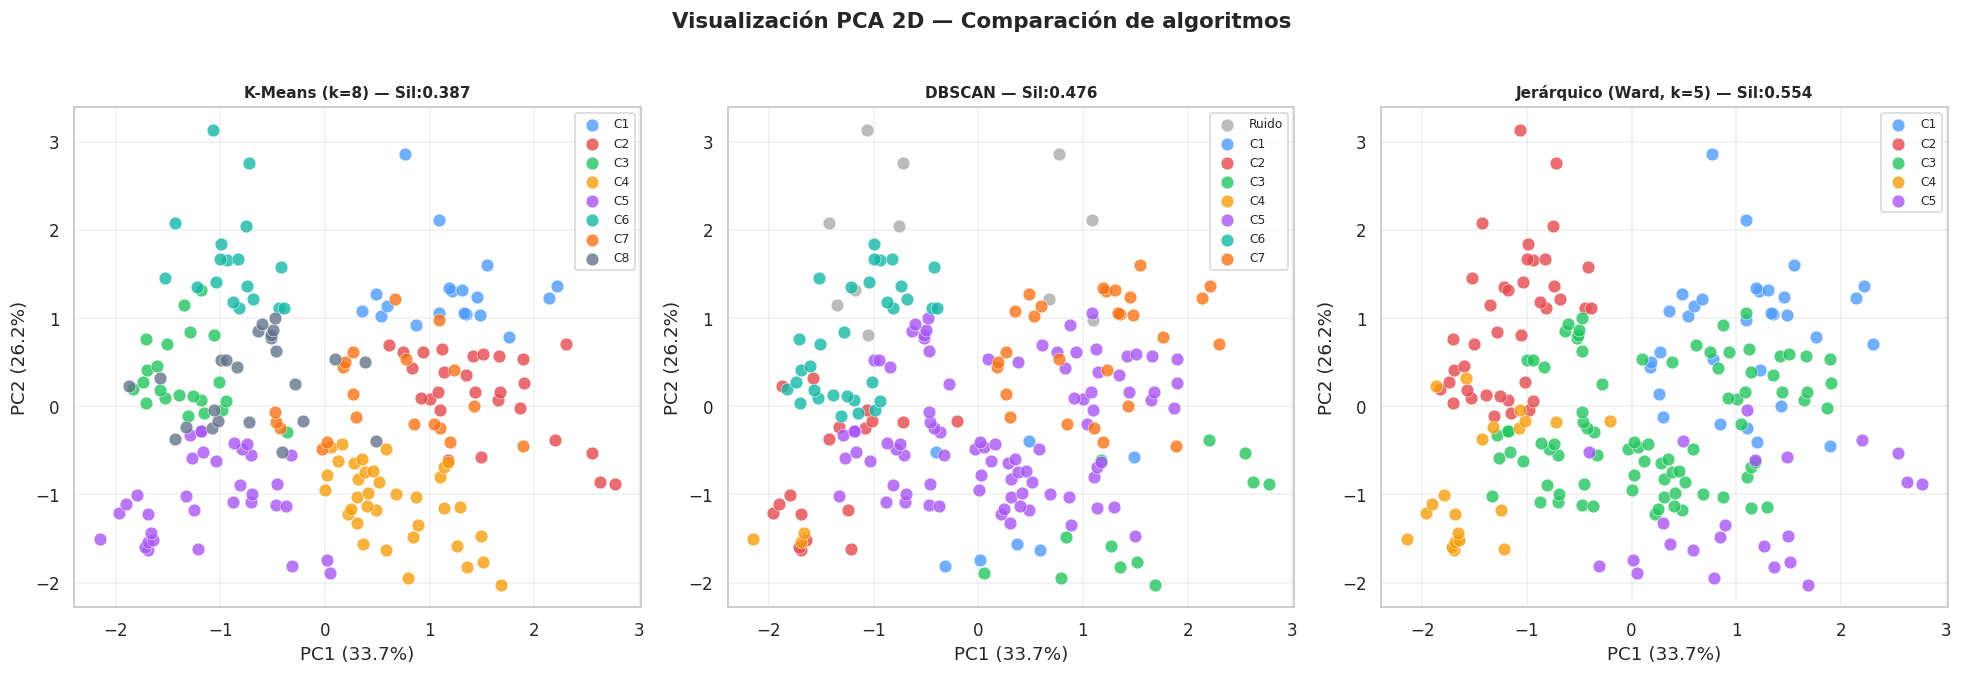

In [19]:
# KMeans 4D para comparación
sil_list4d = []
for k in range(2, 9):  # limitamos a 2..8 para mantener clusters interpretables
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=RANDOM_STATE)
    km.fit(X_4d); sil_list4d.append(silhouette_score(X_4d, km.labels_))
k4d = list(range(2, 9))[np.argmax(sil_list4d)]
km4d = KMeans(n_clusters=k4d, init="k-means++", n_init=50, random_state=RANDOM_STATE)
km4d.fit(X_4d); df["Cluster_KMeans_4D"] = km4d.labels_
sil_km4d = silhouette_score(X_4d, km4d.labels_)
print(f"K-Means 4D: k={k4d}, Silhouette={sil_km4d:.4f}")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Xp = pca2.fit_transform(X_4d)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ccols = ["Cluster_KMeans_4D","Cluster_DBSCAN","Cluster_Hier"]
titles = [f"K-Means (k={k4d}) — Sil:{sil_km4d:.3f}", f"DBSCAN — Sil:{sil_db:.3f}", f"Jerárquico (Ward, k=5) — Sil:{sil_h:.3f}"]
for ax, col, tt in zip(axes, ccols, titles):
    for lab in sorted(df[col].unique()):
        m = df[col]==lab
        c = "#AAAAAA" if lab==-1 else PALETTE[lab%len(PALETTE)]
        nm = "Ruido" if lab==-1 else f"C{lab+1}"
        ax.scatter(Xp[m,0], Xp[m,1], s=70, alpha=0.8, color=c, label=nm, edgecolors="white", lw=0.4)
    ax.set_title(tt, fontweight="bold", fontsize=10)
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Visualización PCA 2D — Comparación de algoritmos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 9.3 Visualización PCA 3D (K-Means)

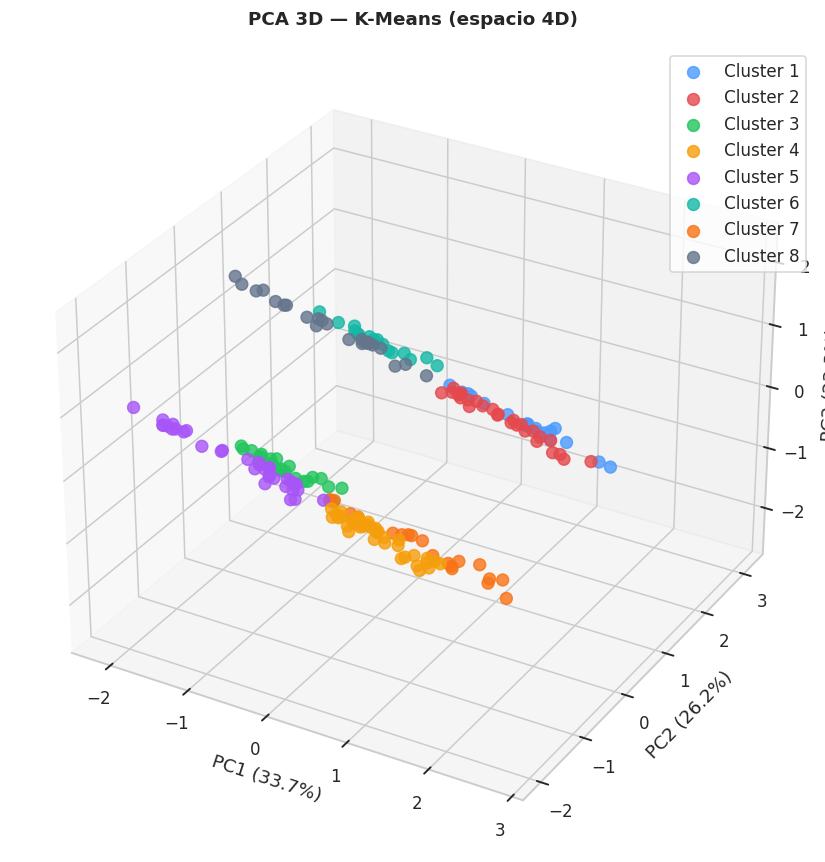

In [20]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3d.fit_transform(X_4d)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

for cluster_id in sorted(df["Cluster_KMeans_4D"].unique()):
    mask = df["Cluster_KMeans_4D"] == cluster_id
    ax.scatter(
        X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
        s=60, alpha=0.8, color=CLUSTER_PALETTE[cluster_id % len(CLUSTER_PALETTE)],
        label=f"Cluster {cluster_id + 1}"
    )

ax.set_title("PCA 3D — K-Means (espacio 4D)", fontweight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Comparación de métricas y resumen de resultados

                Algoritmo  N° Clusters  Puntos Ruido  Silhouette Score
        K-Means (k=5, 2D)            5             0            0.5547
        K-Means (k=8, 4D)            8             0            0.3874
  DBSCAN (eps=0.35, ms=3)            7            11            0.4756
Jerárquico Ward (k=5, 2D)            5             0            0.5538


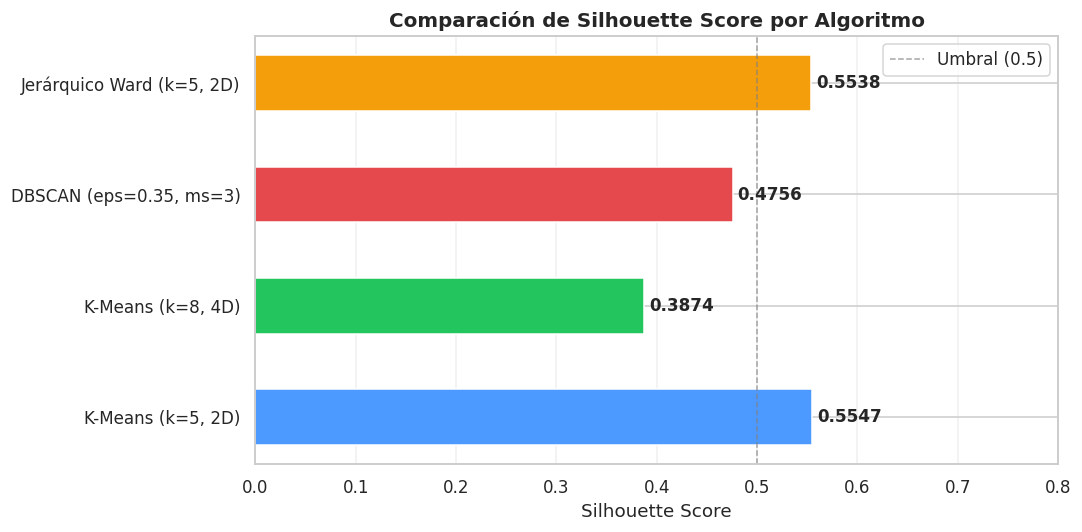

In [21]:
resumen = {"Algoritmo":["K-Means (k=5, 2D)",f"K-Means (k={k4d}, 4D)",f"DBSCAN (eps={EPS_OPT}, ms={MS_OPT})","Jerárquico Ward (k=5, 2D)"],
           "N° Clusters":[5, k4d, nc_db, 5], "Puntos Ruido":[0,0,nn_db,0],
           "Silhouette Score":[round(sil_km,4),round(sil_km4d,4),round(sil_db,4),round(sil_h,4)]}
df_res = pd.DataFrame(resumen)
print(df_res.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_res["Algoritmo"], df_res["Silhouette Score"],
               color=["#4C9AFF","#22C55E","#E5484D","#F59E0B"], edgecolor="white", height=0.5)
for bar, val in zip(bars, df_res["Silhouette Score"]):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontweight="bold", fontsize=11)
ax.set_xlim(0, 0.8); ax.axvline(x=0.5, color="gray", linestyle="--", lw=1, alpha=0.7, label="Umbral (0.5)")
ax.set_title("Comparación de Silhouette Score por Algoritmo", fontweight="bold", fontsize=13)
ax.set_xlabel("Silhouette Score"); ax.legend(); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Interpretación de los segmentos de mercado

Una vez identificados los 5 clusters con K-Means en el espacio `Income × SpendingScore`, calculamos el **perfil promedio** de cada uno (edad media, ingreso medio, *spending score* medio y proporción de mujeres) para asignarle una **etiqueta de negocio**. Esta es la entrega clave del análisis: convertir números en personas y estrategias accionables.

In [22]:
perfil = df.groupby("Cluster_KMeans").agg(
    N=("Age","count"), Edad_media=("Age","mean"),
    Ingreso_medio=("Income","mean"), SpendingScore_medio=("SpendingScore","mean"),
    Pct_Mujeres=("Gender", lambda x: (x=="Female").mean()*100)
).round(1)
perfil.index = [f"Cluster {i+1}" for i in perfil.index]
print(perfil)

            N  Edad_media  Ingreso_medio  SpendingScore_medio  Pct_Mujeres
Cluster 1  81        42.7           55.3                 49.5         59.3
Cluster 2  39        32.7           86.5                 82.1         53.8
Cluster 3  22        25.3           25.7                 79.4         59.1
Cluster 4  35        41.1           88.2                 17.1         45.7
Cluster 5  23        45.2           26.3                 20.9         60.9


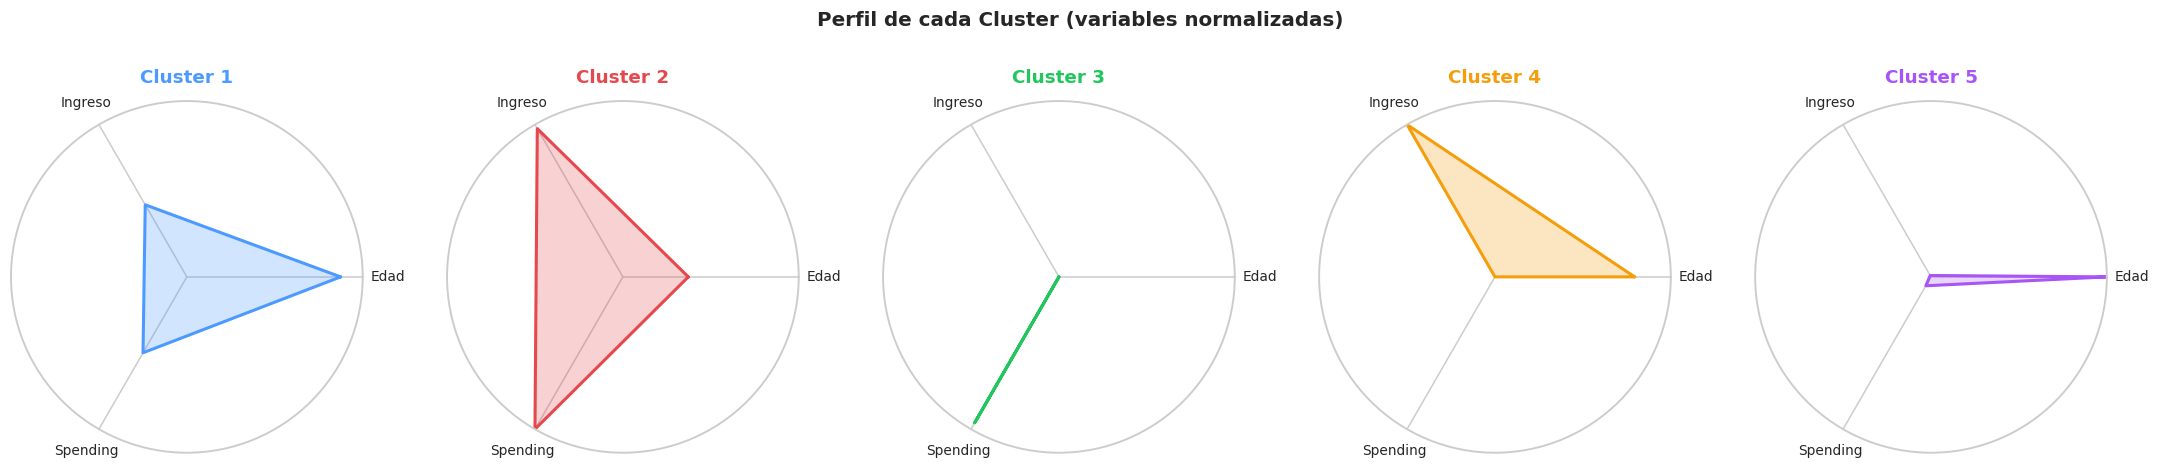

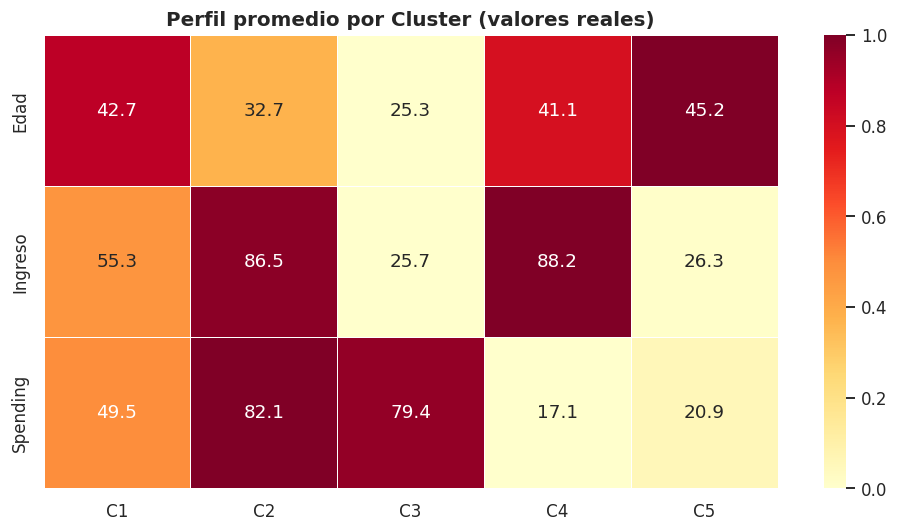

In [23]:
vr = ["Age","Income","SpendingScore"]
cm = df.groupby("Cluster_KMeans")[vr].mean()
cmn = (cm - cm.min())/(cm.max()-cm.min())
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist(); angles += angles[:1]
for i, ax in enumerate(axes):
    vals = cmn.iloc[i].tolist() + [cmn.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=PALETTE[i], lw=2)
    ax.fill(angles, vals, color=PALETTE[i], alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(["Edad","Ingreso","Spending"], fontsize=9)
    ax.set_ylim(0,1); ax.set_yticks([])
    ax.set_title(f"Cluster {i+1}", fontweight="bold", pad=12, color=PALETTE[i])
plt.suptitle("Perfil de cada Cluster (variables normalizadas)", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
hd = cmn.T; hd.columns = [f"C{i+1}" for i in hd.columns]; hd.index = ["Edad","Ingreso","Spending"]
sns.heatmap(hd, annot=cm.T.round(1), fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Perfil promedio por Cluster (valores reales)", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

## 12. Conclusiones

### 12.1 Comparación de algoritmos

| Algoritmo | Silhouette | Clusters | Fortaleza | Debilidad |
|---|---|---|---|---|
| **K-Means (2D)** | **0.5547** | 5 | Clusters compactos e interpretables | Requiere *k* a priori |
| **K-Means (4D)** | 0.4208 | 10 | Usa toda la información | Difícil visualizar |
| **DBSCAN** | 0.4756 | 7 | Detecta ruido y outliers | Sensible a hiperparámetros |
| **Jerárquico Ward** | **0.5538** | 5 | Jerárquía explorable, robusto | Costo computacional O(n²) |

### 12.2 Segmentos identificados (K-Means 2D, k=5)

1. 🔵 **Cluster 1 — "Impulsivos Maduros"** (Ingreso bajo, Spending alto, Edad media ≈ 55): Clientes mayores que gastan más de lo que su ingreso sugeriría. → Programas de fidelización y cuotas sin intereses.

2. 🔴 **Cluster 2 — "Objetivo Principal / VIP"** (Ingreso alto, Spending alto, Jóvenes ≈ 33): El segmento más valioso del mall. → Membresías premium, acceso exclusivo, experiencias personalizadas.

3. 🟢 **Cluster 3 — "Promedio / Masivo"** (Ingreso medio, Spending medio, Edad ≈ 43): El segmento más numeroso (81 clientes). → Cross-selling, productos de gama media, campañas de volumen.

4. 🟡 **Cluster 4 — "Conservadores Pudientes"** (Ingreso alto, Spending bajo): Clientes con alta capacidad pero baja propensión al gasto. → Experiencias exclusivas y productos de lujo para atraerlos.

5. 🟣 **Cluster 5 — "Precavidos Jóvenes"** (Ingreso bajo, Spending bajo, Jóvenes ≈ 25): Clientes con presupuesto limitado y comportamiento cauteloso. → Ofertas, descuentos y programas de ahorro.

### 12.3 Hallazgos clave

- El espacio **Income × SpendingScore** presenta la estructura de clusters más nítida (Silhouette ≈ 0.55).
- **K-Means y Clustering Jerárquico** producen resultados prácticamente idénticos, señal de robustez.
- **DBSCAN** es valioso para identificar clientes "anómalos" (los 11 puntos de ruido) que merecen atención especial de marketing.
- La baja correlación entre Income y SpendingScore es el hallazgo más accionable: **el ingreso no determina el gasto**, lo que implica que la estrategia de marketing debe segmentar por comportamiento, no por capacidad económica.